In [2]:
import pandas as pd
import seaborn as sns
import plotly.express as px

In [3]:
# Importing the dataset

motor_df = pd.read_csv("motor_vehicle_modified.csv", header=0, usecols={"year", "state", "Total Vehicles"})
motor_df = motor_df.query("year >= 2010 & year <= 2020")

aqi_df = pd.read_csv("aqi_modified.csv", header=0, usecols={"Year", "State", "Median AQI"})
aqi_df = aqi_df.query("Year >= 2010 & Year <= 2020")

In [4]:
# Renaming the columns
motor_df.rename(columns={'year': 'Year', 'state': 'State'}, inplace=True)

In [5]:
# Merging the datasets
df = pd.merge(motor_df, aqi_df, on=["Year", "State"],how="left")
df = df.dropna()
df = df.astype({"Median AQI": "int"})

In [6]:
# Converting "Total Vehicles" to integer

df["Total Vehicles"] = (
    df["Total Vehicles"]
    .astype(str)             
    .str.replace(",", "", regex=False)   # remove commas
    .str.replace(" ", "", regex=False)   # remove stray spaces
)

df["Total Vehicles"] = pd.to_numeric(df["Total Vehicles"], errors='coerce')
df["Total Vehicles"] = df["Total Vehicles"].astype(int)

In [7]:
# Mapping state abbreviations to states

state_abbreviation = {
    "Alabama": "AL",
    "Alaska": "AK",
    "Arizona": "AZ",
    "Arkansas": "AR",
    "California": "CA",
    "Colorado": "CO",
    "Connecticut": "CT",
    "Delaware": "DE",
    "District of Columbia" : "DC",
    "Florida": "FL",
    "Georgia": "GA",
    "Hawaii": "HI",
    "Idaho": "ID",
    "Illinois": "IL",
    "Indiana": "IN",
    "Iowa": "IA",
    "Kansas": "KS",
    "Kentucky": "KY",
    "Louisiana": "LA",
    "Maine": "ME",
    "Maryland": "MD",
    "Massachusetts": "MA",
    "Michigan": "MI",
    "Minnesota": "MN",
    "Mississippi": "MS",
    "Missouri": "MO",
    "Montana": "MT",
    "Nebraska": "NE",
    "Nevada": "NV",
    "New Hampshire": "NH",
    "New Jersey": "NJ",
    "New Mexico": "NM",
    "New York": "NY",
    "North Carolina": "NC",
    "North Dakota": "ND",
    "Ohio": "OH",
    "Oklahoma": "OK",
    "Oregon": "OR",
    "Pennsylvania": "PA",
    "Rhode Island": "RI",
    "South Carolina": "SC",
    "South Dakota": "SD",
    "Tennessee": "TN",
    "Texas": "TX",
    "Utah": "UT",
    "Vermont": "VT",
    "Virginia": "VA",
    "Washington": "WA",
    "West Virginia": "WV",
    "Wisconsin": "WI",
    "Wyoming": "WY"
}

df["StateCode"] = df["State"].map(state_abbreviation)

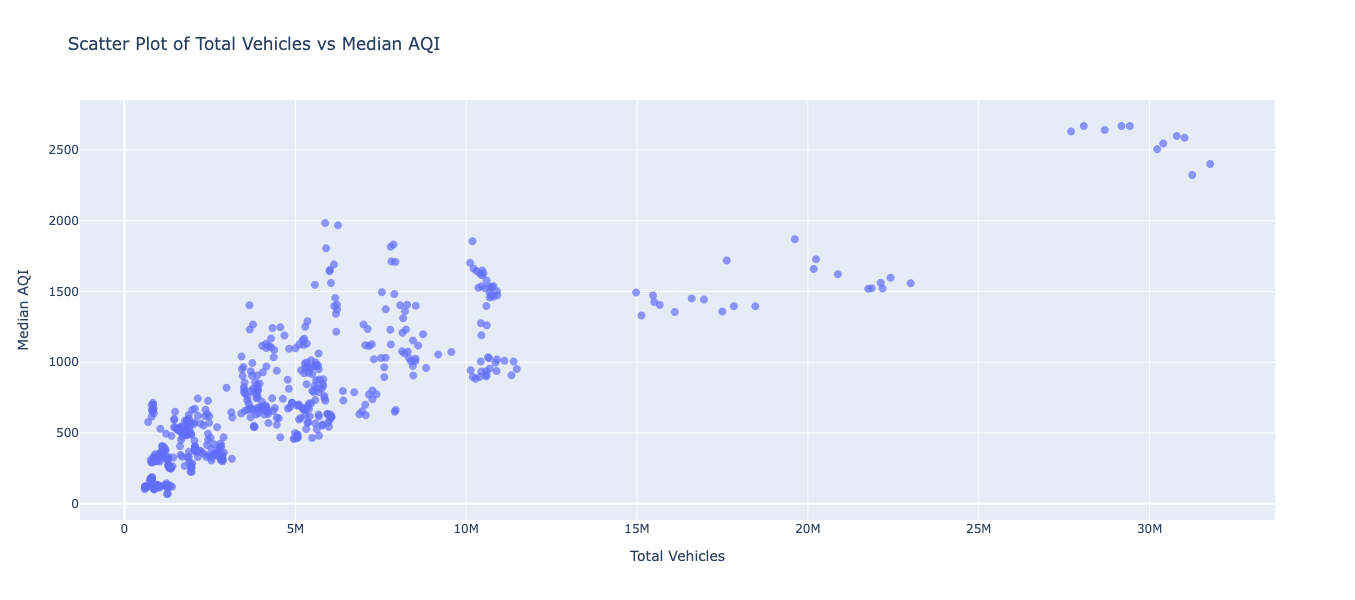

In [8]:
# Scatter plot to check the relationship between total vehicles and median aqi
fig = px.scatter(
    df,
    x="Total Vehicles",
    y="Median AQI",
    hover_name="State",
    labels={
        "Total Vehicles": "Total Vehicles",
        "Median AQI": "Median AQI"
    },
    title="Scatter Plot of Total Vehicles vs Median AQI"
)

fig.update_traces(marker=dict(size=8, opacity=0.7))
fig.update_layout(height=600, width=800)

fig.show()

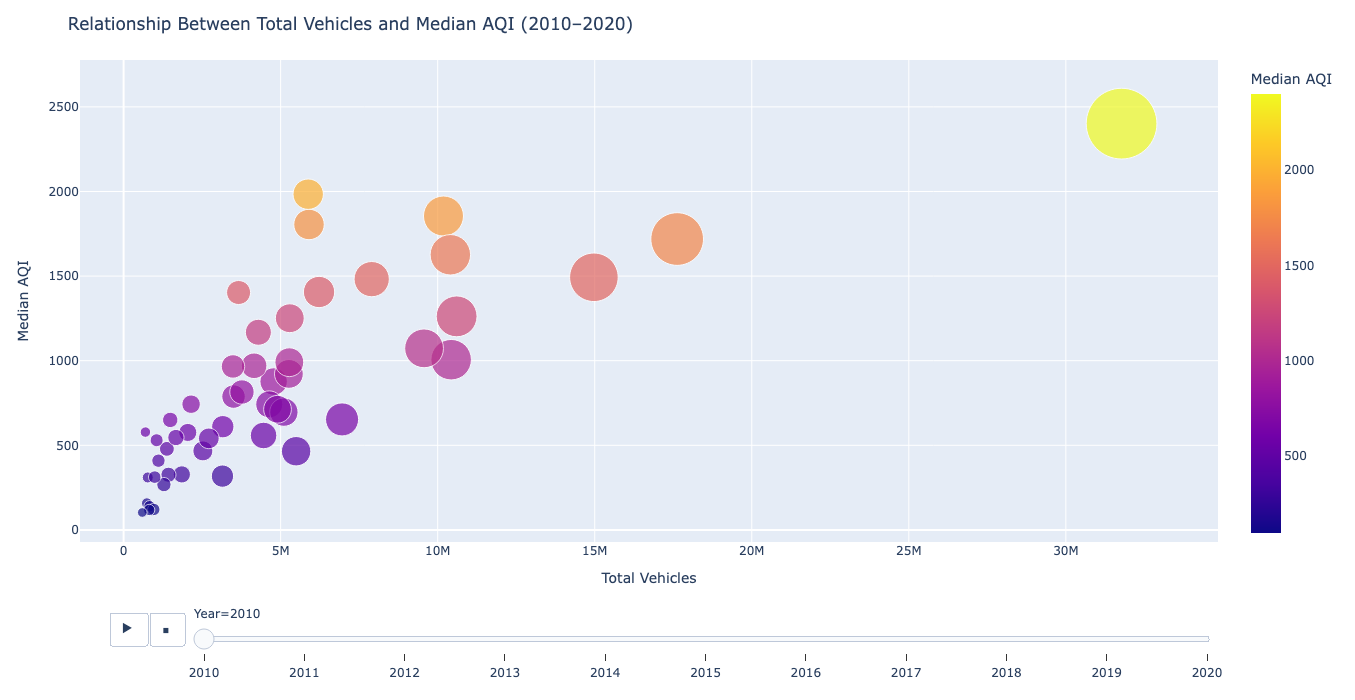

In [9]:
# Intial Idea 

fig = px.scatter(
    df,
    x="Total Vehicles",
    y="Median AQI",
    animation_frame="Year",
    animation_group="State",
    color="Median AQI",              
    hover_name="State",
    size="Total Vehicles",
    size_max=50,
)

fig.update_layout(
    title="Relationship Between Total Vehicles and Median AQI (2010–2020)",
    xaxis_title="Total Vehicles",
    yaxis_title="Median AQI",
    height=700,
)

fig.show()

In [10]:
# Creating a new column to add million denomination to "Total Vehicles"
df['Total Vehicles Hover'] = (df['Total Vehicles'] / 1_000_000).round(1).astype(str) + "m"

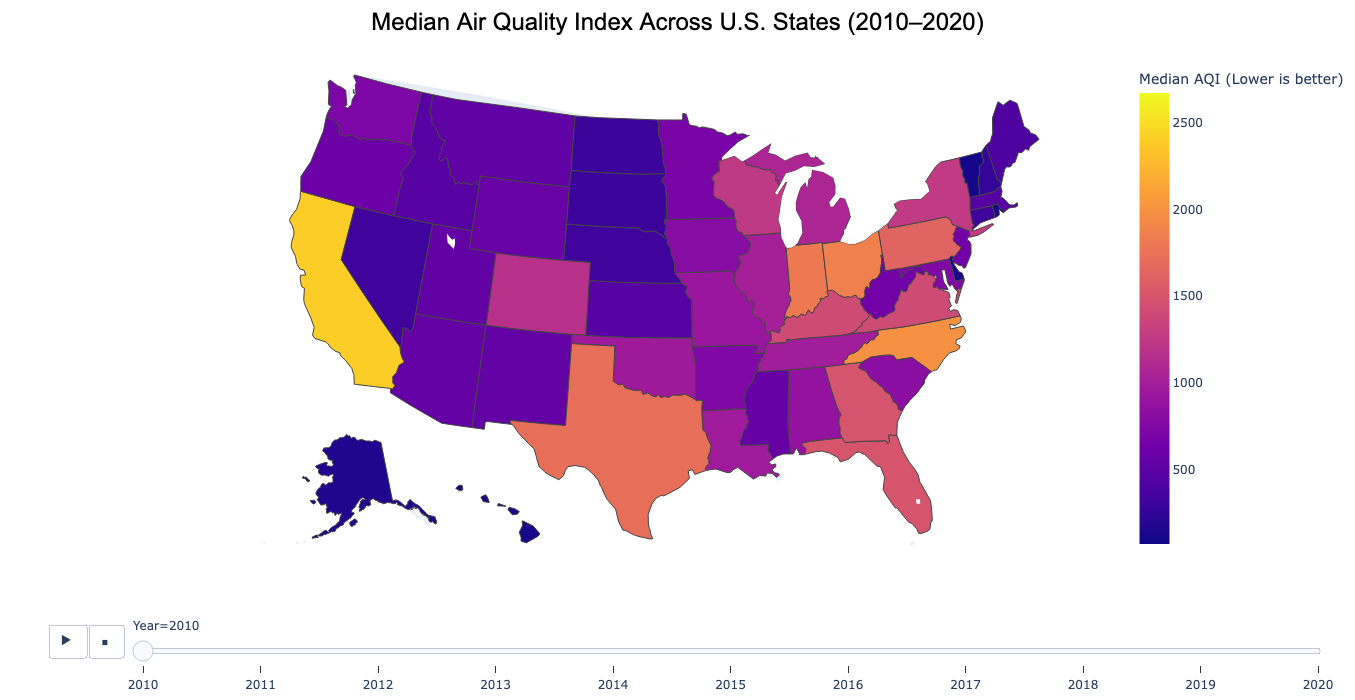

In [11]:
# Finding min and max values for Median AQI
min_aqi = df['Median AQI'].min()
max_aqi = df['Median AQI'].max()

# Creating the Map visualisation
fig = px.choropleth(
    df,
    locations="StateCode",
    locationmode="USA-states",
    color="Median AQI",
    animation_frame="Year",
    hover_name="State",
    hover_data={
        "Total Vehicles Hover": True,
        "Median AQI": True,
        "StateCode": False,
        "Year": False
    },
    color_continuous_scale="Plasma",
    scope="usa",
    range_color=[min_aqi, max_aqi],
    labels={
        "State": "State",
        "Total Vehicles Hover": "Total Vehicles",
        "Median AQI": "Median AQI"
    }
)

fig.update_layout(
    title_text="Median Air Quality Index Across U.S. States (2010–2020)",
    title_x=0.5, 
    title_font=dict(size=24, family="Arial", color="black"),
    height=700,
    width=1200,
    autosize=True,
    margin=dict(l=0, r=0, b=0, t=60, pad=4, autoexpand=True),
    coloraxis_colorbar=dict(title='Median AQI (Lower is better)', xanchor='right')
)

fig.show()

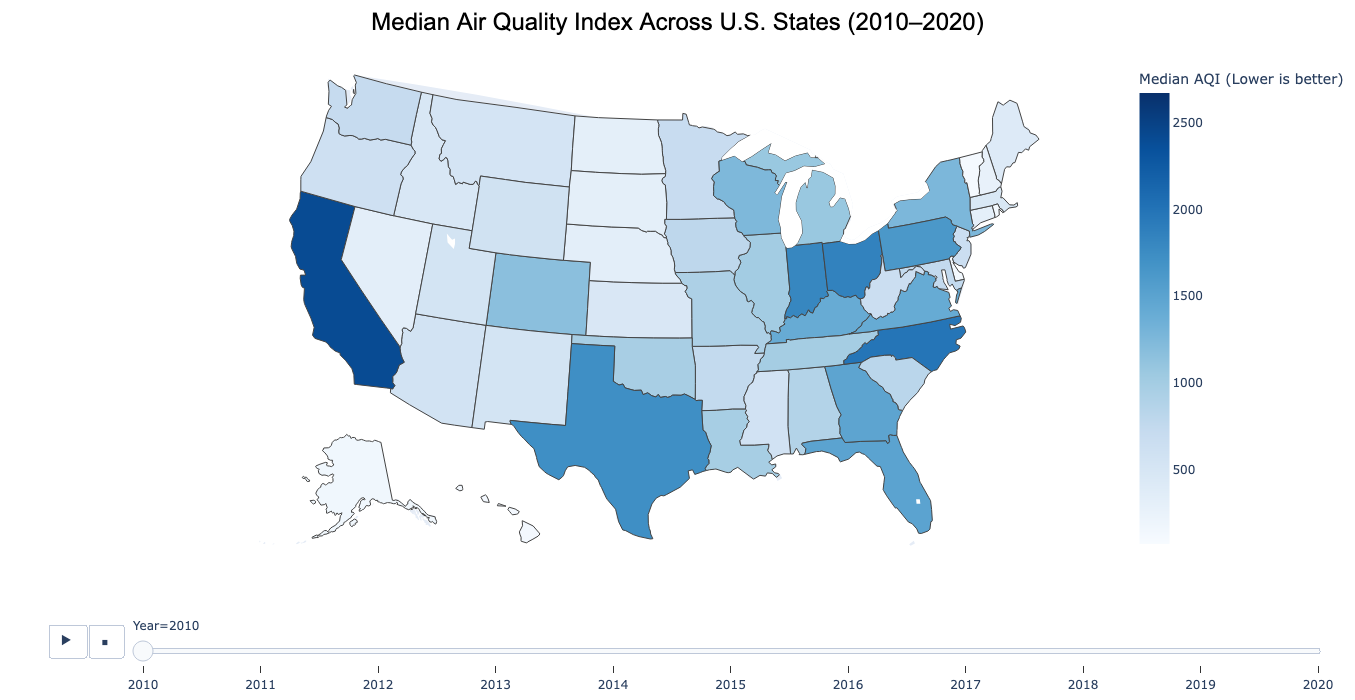

In [12]:
# Finding min and max values for Median AQI
min_aqi = df['Median AQI'].min()
max_aqi = df['Median AQI'].max()

# Creating the Map visualisation
fig = px.choropleth(
    df,
    locations="StateCode",
    locationmode="USA-states",
    color="Median AQI",
    animation_frame="Year",
    hover_name="State",
    hover_data={
        "Total Vehicles Hover": True,
        "Median AQI": True,
        "StateCode": False,
        "Year": False
    },
    color_continuous_scale=px.colors.sequential.Blues,
    scope="usa",
    range_color=[min_aqi, max_aqi],
    labels={
        "State": "State",
        "Total Vehicles Hover": "Total Vehicles",
        "Median AQI": "Median AQI"
    }
)

fig.update_layout(
    title_text="Median Air Quality Index Across U.S. States (2010–2020)",
    title_x=0.5, 
    title_font=dict(size=24, family="Arial", color="black"),
    height=700,
    width=1200,
    autosize=True,
    margin=dict(l=0, r=0, b=0, t=60, pad=4, autoexpand=True),
    coloraxis_colorbar=dict(title='Median AQI (Lower is better)', xanchor='right')
)


In [13]:
df

,Year,State,Total Vehicles,Median AQI,StateCode,Total Vehicles Hover
0,2010,Alabama,4777127,877,AL,4.8m
1,2010,Alaska,740638,158,AK,0.7m
2,2010,Arizona,4456630,558,AZ,4.5m
3,2010,Arkansas,2149105,743,AR,2.1m
4,2010,California,31774179,2401,CA,31.8m
...,...,...,...,...,...,...
556,2020,Virginia,7606452,896,VA,7.6m
557,2020,Washington,7257401,738,WA,7.3m
558,2020,West Virginia,1657362,451,WV,1.7m
559,2020,Wisconsin,5616271,977,WI,5.6m


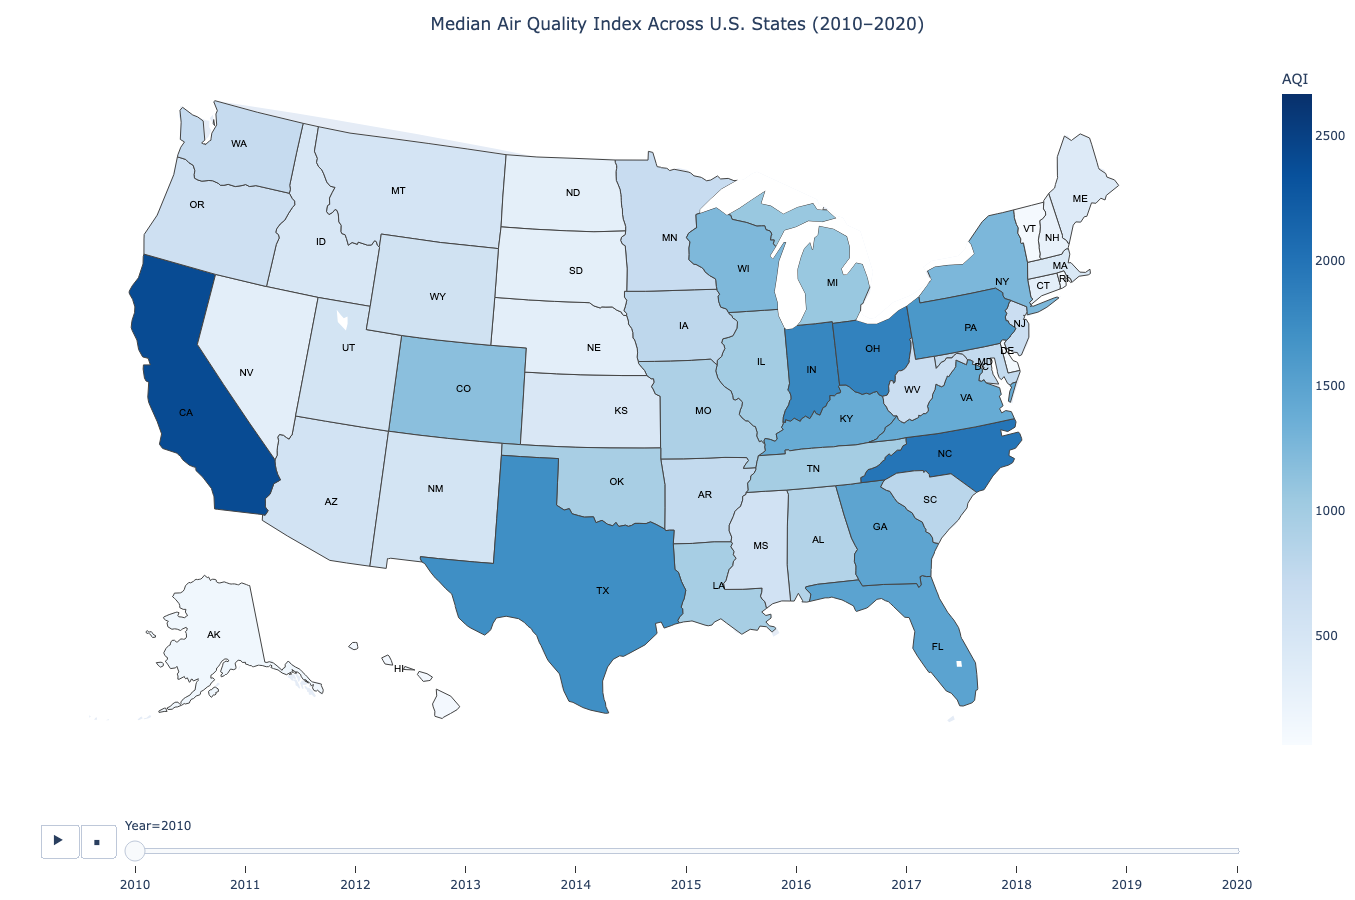

In [15]:
state_centroids = {
    'AL': (32.806671, -86.791130), 'AK': (64.160507, -153.369141),
    'AZ': (33.729759, -111.431221), 'AR': (34.969704, -92.373123),
    'CA': (36.116203, -119.681564), 'CO': (39.059811, -105.311104),
    'CT': (41.597782, -72.755371),  'DE': (39.318523, -75.507141),
    'DC': (38.9072, -77.0369),
    'FL': (27.766279, -81.686783),  'GA': (33.040619, -83.643074),
    'HI': (21.094318, -157.498337), 'ID': (44.240459, -114.478828),
    'IL': (40.349457, -88.986137),  'IN': (39.849426, -86.258278),
    'IA': (42.011539, -93.210526),  'KS': (38.526600, -96.726486),
    'KY': (37.668140, -84.670067),  'LA': (31.169546, -91.867805),
    'ME': (44.693947, -69.381927),  'MD': (39.063946, -76.802101),
    'MA': (42.230171, -71.530106),  'MI': (43.326618, -84.536095),
    'MN': (45.694454, -93.900192),  'MS': (32.741646, -89.678696),
    'MO': (38.456085, -92.288368),  'MT': (46.921925, -110.454353),
    'NE': (41.125370, -98.268082),  'NV': (38.313515, -117.055374),
    'NH': (43.452492, -71.563896),  'NJ': (40.298904, -74.521011),
    'NM': (34.840515, -106.248482), 'NY': (42.165726, -74.948051),
    'NC': (35.630066, -79.806419),  'ND': (47.528912, -99.784012),
    'OH': (40.388783, -82.764915),  'OK': (35.565342, -96.928917),
    'OR': (44.572021, -122.070938), 'PA': (40.590752, -77.209755),
    'RI': (41.680893, -71.511780),  'SC': (33.856892, -80.945007),
    'SD': (44.299782, -99.438828),  'TN': (35.747845, -86.692345),
    'TX': (31.054487, -97.563461),  'UT': (40.150032, -111.862434),
    'VT': (44.045876, -72.710686),  'VA': (37.769337, -78.169968),
    'WA': (47.500902, -120.590494), 'WV': (38.491226, -80.954453),
    'WI': (44.268543, -89.616508),  'WY': (42.755966, -107.302490)
}

centroid_df = pd.DataFrame([
    {"StateCode": k, "lat": v[0], "lon": v[1]}
    for k, v in state_centroids.items()
])

# Base map
fig = px.choropleth(
    df,
    locations="StateCode",
    locationmode="USA-states",
    color="Median AQI",
    animation_frame="Year",
    hover_name="State",
    hover_data={"Total Vehicles Hover": True, "Year": False, "StateCode": False},
    color_continuous_scale=px.colors.sequential.Blues,
    scope="usa",
    range_color=[min_aqi, max_aqi],
    labels={"Median AQI": "AQI", "Total Vehicles Hover": "Total Vehicles"}
)

# Overlay state abbreviation labels
fig.add_scattergeo(
    lat=centroid_df['lat'],
    lon=centroid_df['lon'],
    text=centroid_df['StateCode'],
    mode='text',
    textfont=dict(size=10, color="black", family="Arial"),
    hoverinfo='skip',
    showlegend=False
)

fig.update_layout(
    title_text="Median Air Quality Index Across U.S. States (2010–2020)",
    title_x=0.5,
    height=900,
    width=1400,
    margin=dict(l=0, r=0, b=0, t=60),
    coloraxis_colorbar=dict(title='AQI')
)

fig.show()